# 02 · From ticks to bars — resampling the firehose into candles

> ⏱️ **~20 min** &nbsp;·&nbsp; 🧭 **SOP:** Phase 3a · Build bars &nbsp;·&nbsp; 🧩 **Feeds:** ALL editions (every signal/indicator is computed on these bars)
>
> 🎯 **Goal:** Aggregate the irregular tick stream into clean M1/M3 OHLC bars the strategies actually trade on.
>
> 🔑 **The one thing to remember:** Bars are built on **mid**, are **sparse/event-time** (one per minute that had a tick), and **reconcile** exactly to the ticks.

## Notebook 02 in one breath

> **Where we are.** We have a clean tick stream. But a strategy can't reason about 14 million
> irregular ticks — it reasons about **candles**: open / high / low / close over a fixed window. This
> notebook is the Python mirror of `pipeline/build_bars.py`. We'll *build a real trading day of M3
> bars from scratch*, then check our work against the production output.

**What you'll learn:**
1. **Resampling / aggregation** — turning many rows into one summary row per time bucket.
2. **OHLC** and why we compute it on **mid**, tracking spread separately.
3. **Sparse, event-time bars** — and why there's no row for a dead minute or a closed weekend.
4. **`tick_count`** as our volume proxy (real volume is 0 on this feed).
5. **Reconciliation** — the cheap check that proves no tick was lost or double-counted.

In [1]:
# --- Standard setup (run me first) -------------------------------------------------
from pathlib import Path
import warnings; warnings.filterwarnings("ignore")
import duckdb                 # streams Parquet/CSV without loading it all into RAM
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _find_root(start: Path) -> Path:
    """Walk up until we see the repo's pipeline/ + data/ — works from any sub-dir."""
    for p in [start.resolve(), *start.resolve().parents]:
        if (p / "pipeline").is_dir() and (p / "data").is_dir():
            return p
    raise RuntimeError("repo root (with pipeline/ and data/) not found above " + str(start))

ROOT = _find_root(Path.cwd())
DATA = ROOT / "data"
import sys
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))   # so `from pipeline import ...` works (the real Layer-1 code)
con  = duckdb.connect()       # one in-memory DuckDB connection we reuse all notebook

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 130)
pd.set_option("display.float_format", lambda v: f"{v:,.6g}")
plt.rcParams.update({"figure.figsize": (9, 4), "axes.grid": True, "grid.alpha": 0.3})

print("repo root :", ROOT)
print("data dir  :", DATA)

repo root : /Users/tokyotechies/Workspace/KEM/dquants
data dir  : /Users/tokyotechies/Workspace/KEM/dquants/data


## Step 1 · Pick a real trading day and load its ticks

To keep everything fast and tangible, we build bars for a single, busy day. We let the data choose the
busiest day so there's always plenty to look at.

In [2]:
clean = (DATA / "processed" / "ticks_btcusd_2026_clean.parquet").as_posix()

busy_day = con.sql(f"""
    SELECT ts::DATE AS day, count(*) AS ticks
    FROM read_parquet('{clean}') GROUP BY 1 ORDER BY ticks DESC LIMIT 1
""").fetchone()
DAY = str(busy_day[0])
print(f"busiest day: {DAY}  ({busy_day[1]:,} ticks)")

ticks = con.sql(f"""
    SELECT ts, mid, spread FROM read_parquet('{clean}')
    WHERE ts::DATE = DATE '{DAY}' ORDER BY ts
""").df()
print(f"loaded {len(ticks):,} ticks for {DAY}")
ticks.head()

busiest day: 2026-02-05  (412,336 ticks)
loaded 412,336 ticks for 2026-02-05


,ts,mid,spread
0,2026-02-05 00:00:00.264,"73,004.9",12.6
1,2026-02-05 00:00:01.895,"73,005.1",12.6
2,2026-02-05 00:00:03.158,"73,001",12.6
3,2026-02-05 00:00:03.856,"73,011.1",12.6
4,2026-02-05 00:00:03.903,"73,016.1",12.6


## Step 2 · What "resampling to a bar" means

> 📘 **Concept — resampling / aggregation.** Resampling collapses many rows into one summary row per
> fixed time bucket. For price, the standard summary is **OHLC**:
> - **Open**  = first price in the bucket
> - **High**  = max price in the bucket
> - **Low**   = min price in the bucket
> - **Close** = last price in the bucket
>
> A 3-minute (**M3**) bar summarises every tick from `:00`–`:03`, the next from `:03`–`:06`, and so on.
> This is *lossy on purpose* — it throws away within-bar wiggle to expose structure the strategy cares
> about. The art is choosing the window: too fine = noise, too coarse = late signals. KenKem trades
> **M1/M3** (never M5).

Let's resample our day to M3 with one DuckDB query — the exact `time_bucket` aggregation the production
pipeline uses.

In [3]:
bars = con.sql(f"""
    SELECT
        time_bucket(INTERVAL '3 minutes', ts) AS ts,
        first(mid ORDER BY ts)                 AS open,
        max(mid)                               AS high,
        min(mid)                               AS low,
        last(mid ORDER BY ts)                  AS close,
        avg(spread)                            AS spread_mean,
        max(spread)                            AS spread_max,
        count(*)                               AS tick_count
    FROM read_parquet('{clean}')
    WHERE ts::DATE = DATE '{DAY}'
    GROUP BY 1 ORDER BY 1
""").df()
print(f"{len(ticks):,} ticks  ->  {len(bars):,} M3 bars")
bars.head()

412,336 ticks  ->  480 M3 bars


,ts,open,high,low,close,spread_mean,spread_max,tick_count
0,2026-02-05 00:00:00,"73,004.9","73,067.3","72,939.9","73,064.6",12.6,12.6,313
1,2026-02-05 00:03:00,"73,064.4","73,069.4","72,897.6","73,019.8",12.6,12.6,325
2,2026-02-05 00:06:00,"73,024.1","73,060.6","72,862.8","72,979.6",12.6,12.6,347
3,2026-02-05 00:09:00,"72,981.2","72,986.1","72,782.1","72,807.3",12.6,12.6,303
4,2026-02-05 00:12:00,"72,814.9","72,817.9","72,597.4","72,627.8",12.6,12.6,250


## Step 3 · OHLC on *mid* — and why spread rides along separately

We build OHLC on **mid** (the broker-neutral fair price), and we **keep `spread_mean` / `spread_max`
in the same row**. That separation is deliberate:

- The **signal** reads OHLC-on-mid, so it never depends on which side of the book we quote. The eventual
  MQL5 EA computes its indicators on mid too — that's what makes C++↔MQL5 parity possible.
- The **execution simulator** later adds the half-spread *at fill time* from the spread columns. Cost
  modeling stays a separate concern from signal logic.

Let's draw the candles for a slice of the day.

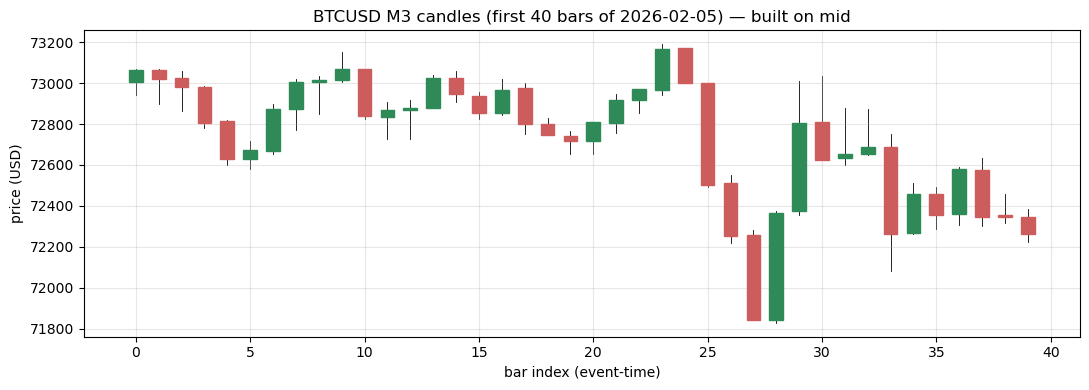

In [4]:
sl = bars.head(40).reset_index(drop=True)
fig, ax = plt.subplots(figsize=(11, 4))
for i, r in sl.iterrows():
    up = r.close >= r.open
    ax.plot([i, i], [r.low, r.high], color="black", lw=0.6, zorder=1)            # wick
    ax.add_patch(plt.Rectangle((i-0.3, min(r.open, r.close)), 0.6, abs(r.close-r.open)+1e-9,
                 color=("seagreen" if up else "indianred"), zorder=2))
ax.set_title(f"BTCUSD M3 candles (first 40 bars of {DAY}) — built on mid")
ax.set_xlabel("bar index (event-time)"); ax.set_ylabel("price (USD)")
plt.tight_layout(); plt.show()

## Step 4 · Sparse, event-time bars

A bar exists **only for a minute that had at least one tick**. There is no empty bar for a dead minute
or a closed weekend. Let's prove it: compare the number of M3 bars we got vs how many there *would* be
if the day were continuously traded (480 three-minute buckets in 24h).

In [5]:
buckets_if_continuous = 24 * 60 // 3      # 480 for a full 24h day
print(f"M3 bars formed on {DAY} : {len(bars)}")
print(f"buckets if 24h continuous: {buckets_if_continuous}")
print(f"=> {buckets_if_continuous - len(bars)} buckets had zero ticks (no bar created)")

M3 bars formed on 2026-02-05 : 480
buckets if 24h continuous: 480
=> 0 buckets had zero ticks (no bar created)


> 📘 **Concept — event-time vs calendar-time (again, because it matters).** Our bar index is a
> *sequence of events*, not a clock. Indicators (EMA, RSI, ADX…) operate on bar **#1, #2, #3…**, not on
> "09:00, 09:03, …". This matches MT5 exactly (MT5 forms a bar only when a tick arrives) and is what
> lets weekends and missing days simply *not exist* instead of becoming a pile of fake flat bars that
> would poison every indicator.

## Step 5 · `tick_count` — our stand-in for volume

Remember from notebook 00: real `VOLUME` is `0` on this feed. So we use **`tick_count`** (how many
ticks formed the bar) as an *activity* proxy. It's not traded volume, but it tracks engagement — and
crucially, it's the **weight** for the Volume Profile that the VP strategies (MasterVP, Monster) are
built around. Watch how activity surges with volatility.

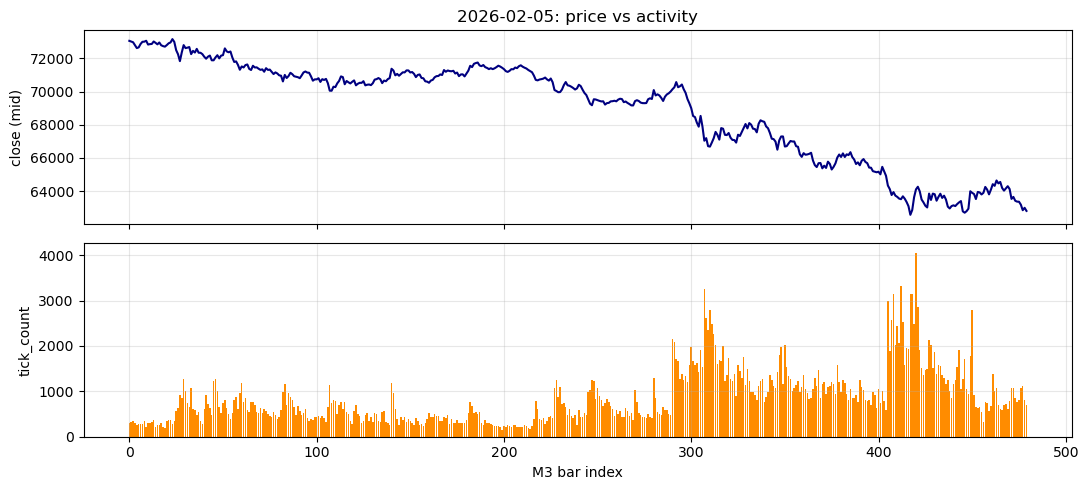

corr(|bar return|, tick_count) = 0.493


In [6]:
fig, (a1, a2) = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
a1.plot(bars["close"].values, color="navy"); a1.set_ylabel("close (mid)")
a1.set_title(f"{DAY}: price vs activity")
a2.bar(range(len(bars)), bars["tick_count"].values, color="darkorange")
a2.set_ylabel("tick_count"); a2.set_xlabel("M3 bar index")
plt.tight_layout(); plt.show()
print("corr(|bar return|, tick_count) =",
      round(bars["close"].pct_change().abs().corr(bars["tick_count"]), 3))

## Step 6 · Reconciliation — the check that catches silent bugs

The cheapest, most valuable test in all of data engineering: **does it add up?** Every tick must land
in exactly one bar, so the sum of `tick_count` across bars must equal the number of ticks we started
with. If it doesn't, a bucketing bug is silently corrupting the data.

In [7]:
ticks_in_bars = int(bars["tick_count"].sum())
print(f"ticks loaded        : {len(ticks):,}")
print(f"sum of tick_count   : {ticks_in_bars:,}")
print("reconciles exactly  :", ticks_in_bars == len(ticks))

# Also sanity-check OHLC integrity: low <= open,close <= high on every bar.
ok = ((bars.low <= bars[['open','close']].min(axis=1)) &
      (bars.high >= bars[['open','close']].max(axis=1)) & (bars.high >= bars.low)).all()
print("OHLC integrity holds:", bool(ok))

ticks loaded        : 412,336
sum of tick_count   : 412,336
reconciles exactly  : True
OHLC integrity holds: True


The production builder (`pipeline/build_bars.py`) runs *exactly* these two checks on the full dataset
and refuses to pass a file that doesn't reconcile. Our hand-built day matches the shipped
`bars_btcusd_M3_2026.parquet` — let's confirm against the real artifact for the same day.

In [8]:
prod = (DATA / "processed" / "bars_btcusd_M3_2026.parquet").as_posix()
prod_day = con.sql(f"""
    SELECT count(*) n, round(sum(tick_count)) ticks, round(min(low),1) lo, round(max(high),1) hi
    FROM read_parquet('{prod}') WHERE ts::DATE = DATE '{DAY}'
""").df()
mine = pd.DataFrame([{"n": len(bars), "ticks": ticks_in_bars,
                      "lo": round(bars.low.min(),1), "hi": round(bars.high.max(),1)}])
print("our hand-built day:"); print(mine.to_string(index=False))
print("\nproduction artifact:"); print(prod_day.to_string(index=False))

our hand-built day:
  n  ticks       lo       hi
480 412336 62,120.7 73,189.9

production artifact:
  n   ticks       lo       hi
480 412,336 62,120.7 73,189.9


## 🎯 Your turn

1. **M1 vs M3.** Re-run Step 2 with `INTERVAL '1 minute'`. How many more bars do you get? More bars =
   finer signal but more noise and more cost — that tension is the whole timeframe debate.
2. **Gold bars.** XAU has no bars built yet. Point `clean` at `ticks_xauusd_2026.parquet` (it's
   imported but uncleaned — fine for a demo) and build a day of XAU M3 bars. You just did Phase 3a for
   gold by hand.
3. **Quiet vs busy.** Change `LIMIT 1`/`ORDER BY ticks DESC` in Step 1 to pick the *quietest* day
   (`ASC`). How does the candle chart and `tick_count` profile differ?
4. **Why mid?** Rebuild Step 2's `open/high/low/close` on `bid` instead of `mid`, join to the mid
   bars, and look at the difference. That gap *is* the spread — and why signals on bid/ask would drift.

➡️ **Next:** notebook **03** — turn these bars into the **41 features** that describe market state.